In [3]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import timm
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import pandas as pd

# Disable the Windows Symlink Warning for HuggingFace/Timm
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Baseline Pre-Trained Face Model

In [11]:
base_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
checkpoint = torch.load(r"C:\Users\kaksh\Documents\SMU MITB\mae_face_pretrain_vit_base.pth", map_location='cpu')
base_model.load_state_dict(checkpoint['model'], strict=False)
base_model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

# Disguise Model

In [4]:
class SejongFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, allowed_subjects=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.disguise_types = []
        
        # Global map to keep integer labels consistent across splits
        self.subject_to_idx = {}
        idx_counter = 0
        
        # Scan everything first to build the global ID map
        for img_path in self.root_dir.rglob('*_v.jpg'):
            if img_path.is_file():
                rel_path = img_path.relative_to(self.root_dir)
                parts = rel_path.parts
                
                subj_id = None
                disguise = None
                
                if parts[0] == "Subset-A" and len(parts) >= 5:
                    subj_id, disguise = f"A_{parts[2]}", parts[3]
                elif parts[0] == "Subset-B" and len(parts) >= 4:
                    subj_id, disguise = f"B_{parts[1]}", parts[2]
                
                if subj_id:
                    if subj_id not in self.subject_to_idx:
                        self.subject_to_idx[subj_id] = idx_counter
                        idx_counter += 1
                    
                    # Filtering: Only add if this subject belongs in this split
                    if allowed_subjects is None or subj_id in allowed_subjects:
                        self.image_paths.append(str(img_path))
                        self.labels.append(self.subject_to_idx[subj_id])
                        self.disguise_types.append(disguise)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img, 
            'label': self.labels[idx], 
            'disguise': self.disguise_types[idx]
        }

In [5]:
class FaceMAE_Contrastive(nn.Module):
    def __init__(self, embedding_size=512, pretrained_path=r"C:\Users\kaksh\Documents\SMU MITB\mae_face_pretrain_vit_base.pth"):
        super(FaceMAE_Contrastive, self).__init__()
        
        # 1. Initialize ViT-B/16 (Architecture only)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
        
        # 2. Load specialized Face-MAE Weights
        if os.path.exists(pretrained_path):
            checkpoint = torch.load(pretrained_path, map_location='cpu')
            # Face-MAE usually stores weights under a 'model' key
            msg = self.backbone.load_state_dict(checkpoint['model'], strict=False)
            print(f"🧠 Face-MAE Weights Loaded. Missing keys: {len(msg.missing_keys)}")
        else:
            print("⚠️ Pretrained Face-MAE path not found. Falling back to ImageNet.")
            self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        # 3. Your Forensic Projection Head
        self.projection_head = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, embedding_size)
        )

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.projection_head(features)
        return F.normalize(embeddings, p=2, dim=1)

In [6]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        
        logits = torch.div(torch.matmul(features, features.T), self.temperature)
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()

        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(batch_size).view(-1, 1).to(device), 0)
        mask = mask * logits_mask
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-6)
        return -mean_log_prob_pos.mean()

In [10]:
# Standard ViT Transforms (Must be 224 for Patch16)
vit_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset_path = r"C:\Users\kaksh\Documents\SMU MITB\Sejong Face Database"

# 1. Get all unique Subject IDs
full_ds = SejongFaceDataset(root_dir=dataset_path)
all_ids = list(full_ds.subject_to_idx.keys())
random.seed(42)
random.shuffle(all_ids)

# 2. Split IDs
train_split = int(0.8 * len(all_ids))
val_split = int(0.9 * len(all_ids))

train_ids = all_ids[:train_split]
val_ids = all_ids[train_split:val_split]
test_ids = all_ids[val_split:]

# 3. Create DataLoaders
train_loader = DataLoader(SejongFaceDataset(dataset_path, vit_transforms, train_ids), batch_size=64, shuffle=True)
val_loader = DataLoader(SejongFaceDataset(dataset_path, vit_transforms, val_ids), batch_size=64, shuffle=False)
test_loader = DataLoader(SejongFaceDataset(dataset_path, vit_transforms, test_ids), batch_size=64, shuffle=False)

print(f"Identities -> Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Identities -> Train: 102, Val: 13, Test: 13


In [8]:
def run_training(epochs=30,lr=1e-4):
    model = FaceMAE_Contrastive().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    criterion = SupConLoss(temperature=0.1).to(device)
    
    # Track history for plotting later
    history = {'train_loss': [], 'val_loss': [], 'val_score': []}
    
    for epoch in range(epochs):
        # --- TRAIN PHASE ---
        model.train()
        total_train_loss = 0
        
        # We add more decimal places to the tqdm postfix to catch small movements
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for batch in pbar:
            imgs, labels = batch['image'].to(device), batch['label'].to(device)
            
            optimizer.zero_grad()
            embs = model(imgs)
            loss = criterion(embs, labels)
            
            # Check for NaN or collapsing loss
            if torch.isnan(loss):
                print("⚠️ Warning: NaN loss detected. Reducing learning rate or checking labels.")
                break
                
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            
            # LIVE UPDATE: Show loss with 6 decimal places to see micro-movements
            pbar.set_postfix({
                'loss': f"{loss.item():.6f}",
                'lr': f"{optimizer.param_groups[0]['lr']:.2e}"
            })

        avg_train_loss = total_train_loss / len(train_loader)

        # --- VALIDATE PHASE (POST-EPOCH) ---
        model.eval()
        total_val_loss = 0
        all_embs, all_lbls = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                imgs, labels = batch['image'].to(device), batch['label'].to(device)
                embs = model(imgs)
                total_val_loss += criterion(embs, labels).item()
                all_embs.append(embs.cpu())
                all_lbls.append(labels.cpu())

        # Scoring Logic: Distance between same identities vs strangers
        all_embs, all_lbls = torch.cat(all_embs), torch.cat(all_lbls)
        sim_matrix = torch.matmul(all_embs, all_embs.T)
        truth_matrix = (all_lbls.unsqueeze(0) == all_lbls.unsqueeze(1)).float()
        
        mask = torch.eye(sim_matrix.size(0)).bool()
        pos_sim = sim_matrix[truth_matrix == 1].mean().item()
        neg_sim = sim_matrix[truth_matrix == 0].mean().item()
        val_score = pos_sim - neg_sim # Higher is better!

        avg_val_loss = total_val_loss / len(val_loader)
        
        # Save to history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_score'].append(val_score)

        # Final Epoch Summary
        print(f"\n✅ Epoch {epoch+1} Results:")
        print(f"   Avg Train Loss: {avg_train_loss:.6f} | Avg Val Loss: {avg_val_loss:.6f}")
        print(f"   Identity Separation Score: {val_score:.4f} (Pos: {pos_sim:.3f}, Neg: {neg_sim:.3f})")
        print("-" * 50)

        # Save Best Model based on Validation Score
        if val_score == max(history['val_score']):
            torch.save(model.state_dict(), r"C:\Users\kaksh\Documents\SMU MITB\best_disguise_blind_vit.pth")
            print("💾 New Best Model Saved!")

    return history

# Run the training
history = run_training(epochs=10)

🧠 Face-MAE Weights Loaded. Missing keys: 0


NameError: name 'train_loader' is not defined

# Evaluation of Models

In [12]:
# 1. Initialize the empty architecture 
# (It will briefly load the base Face-MAE weights or ImageNet weights depending on your class default)
model_ft_2 = FaceMAE_Contrastive().to(device)

# 2. Overwrite with your trained Epoch 7 weights
model_ft_2.load_state_dict(torch.load(r"C:\Users\kaksh\Documents\SMU MITB\best_disguise_blind_vit_epoch_7.pth"))

# 3. CRITICAL: Lock the brain into "Inference Mode"
model_ft_2.eval()

print("✅ Epoch 7 'Brain' successfully loaded and locked for testing!")

🧠 Face-MAE Weights Loaded. Missing keys: 0
✅ Epoch 7 'Brain' successfully loaded and locked for testing!


In [13]:
# Testing on Sejong Database

from sklearn.metrics import roc_curve, auc

def run_forensic_test(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    all_embeddings = []
    all_labels = []
    all_disguises = []
    
    print("Testing 'Brain' on unseen identities...")
    
    with torch.no_grad():
        for batch in tqdm(test_loader):
            imgs = batch['image'].to(device)
            labels = batch['label']
            disguise = batch['disguise']
            
            # Extract 512-d embeddings
            embeddings = model(imgs)
            
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_disguises.extend(disguise)
            
    all_embeddings = torch.cat(all_embeddings)
    all_labels = torch.cat(all_labels)
    
    # 1. Calculate Similarity Matrix (N x N)
    # Since embeddings are L2 normalized, matmul is exactly Cosine Similarity
    sim_matrix = torch.matmul(all_embeddings, all_embeddings.T)
    
    # 2. Create Ground Truth Matrix (1 if same person, 0 if different)
    truth_matrix = (all_labels.unsqueeze(0) == all_labels.unsqueeze(1)).float()
    
    # 3. Flatten and remove self-comparisons (diagonal)
    mask = torch.eye(sim_matrix.size(0)).bool()
    similarities = sim_matrix[~mask].view(-1).numpy()
    targets = truth_matrix[~mask].view(-1).numpy()
    
    # 4. Calculate ROC and AUC
    fpr, tpr, thresholds = roc_curve(targets, similarities)
    roc_auc = auc(fpr, tpr)
    
    # 5. Find TAR at 0.1% FAR (Standard forensic benchmark)
    target_far = 0.001
    idx = np.argmin(np.abs(fpr - target_far))
    tar_at_far = tpr[idx]
    threshold_at_far = thresholds[idx]

    print(f"\n🚀 FINAL TEST RESULTS (Unknown Subjects):")
    print(f"   AUC Score: {roc_auc:.4f}")
    print(f"   TAR @ 0.1% FAR: {tar_at_far:.4f} (Threshold: {threshold_at_far:.3f})")
    print("-" * 40)
    
    return similarities, targets, all_disguises

# Run the test
sims, targets, disguises = run_forensic_test(model_ft_2, test_loader)

Testing 'Brain' on unseen identities...


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:26<00:00,  1.68s/it]



🚀 FINAL TEST RESULTS (Unknown Subjects):
   AUC Score: 0.9869
   TAR @ 0.1% FAR: 0.9276 (Threshold: 0.644)
----------------------------------------


Analyzing Pro-CV: 100%|████████████████████████████████████████████████████████████| 6102/6102 [15:17<00:00,  6.65it/s]


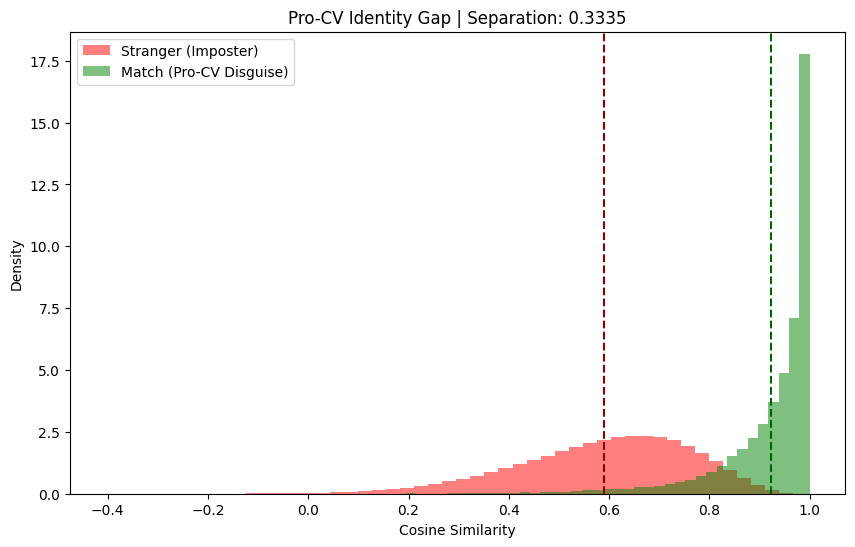

📊 PRO-CV RESULTS
Mean Match: 0.9231
Mean Stranger: 0.5896
SEPARATION GAP: 0.3335


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pathlib import Path
from tqdm import tqdm

# ==========================================
# 1. SETUP (Ensure paths match your PC)
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pro_cv_path = r"C:\Users\kaksh\Documents\SMU MITB\Pro_CV_Disguise_flat"
# ==========================================
# 2. THE UNIVERSAL EXTRACTOR (With L2 Fix)
# ==========================================
vit_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def extract_vector(model, img_path, device):
    try:
        img = Image.open(img_path).convert('RGB')
        img_t = vit_transforms(img).unsqueeze(0).to(device)
        with torch.no_grad():
            # Handle both raw ViT and our Wrapper
            features = model.encoder(img_t) if hasattr(model, 'encoder') else model(img_t)
            normalized_features = F.normalize(features, p=2, dim=1)
        return normalized_features.cpu().numpy().flatten()
    except Exception:
        return None

# ==========================================
# 3. ANALYSIS LOOP (Look for 'pro_' files)
# ==========================================
def run_pro_cv_gap_analysis(model, dataset_root):
    dataset_path = Path(dataset_root)
    all_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    match_scores = []
    original_embs = []

    for person_dir in tqdm(all_dirs, desc="Analyzing Pro-CV"):
        all_imgs = list(person_dir.glob('*.[jp][pn][g]*'))
        orig_path = next((i for i in all_imgs if "00_original" in i.name), None)
        # Look specifically for our landmark-anchored disguises
        pro_paths = [i for i in all_imgs if "pro_" in i.name]
        
        if orig_path and pro_paths:
            o_emb = extract_vector(model, orig_path, device)
            if o_emb is not None:
                original_embs.append(o_emb)
                for p_path in pro_paths:
                    p_emb = extract_vector(model, p_path, device)
                    if p_emb is not None:
                        match_scores.append(np.dot(o_emb, p_emb))

    # Calculate Stranger Scores
    imposter_matrix = np.vstack(original_embs)
    sim_matrix = np.dot(imposter_matrix, imposter_matrix.T)
    mask = np.ones(sim_matrix.shape, dtype=bool)
    np.fill_diagonal(mask, False)
    stranger_scores = sim_matrix[mask]

    return np.array(match_scores), stranger_scores



In [ ]:
# ==========================================
# 4. EXECUTE & PLOT
# ==========================================
# Load Fine-Tuned Model (Using the fixed loader logic)

matches, strangers = run_pro_cv_gap_analysis(model_ft_2, pro_cv_path)

# Final Visualization
plt.figure(figsize=(10, 6))
plt.hist(strangers, bins=50, alpha=0.5, color='red', label='Stranger (Imposter)', density=True)
plt.hist(matches, bins=50, alpha=0.5, color='green', label='Match (Pro-CV Disguise)', density=True)
plt.axvline(x=np.mean(strangers), color='darkred', linestyle='--')
plt.axvline(x=np.mean(matches), color='darkgreen', linestyle='--')

gap = np.mean(matches) - np.mean(strangers)
plt.title(f'Pro-CV Identity Gap | Separation: {gap:.4f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"📊 PRO-CV RESULTS")
print(f"Mean Match: {np.mean(matches):.4f}")
print(f"Mean Stranger: {np.mean(strangers):.4f}")
print(f"SEPARATION GAP: {gap:.4f}")

Analyzing Pro-CV: 100%|████████████████████████████████████████████████████████████| 6102/6102 [10:16<00:00,  9.90it/s]


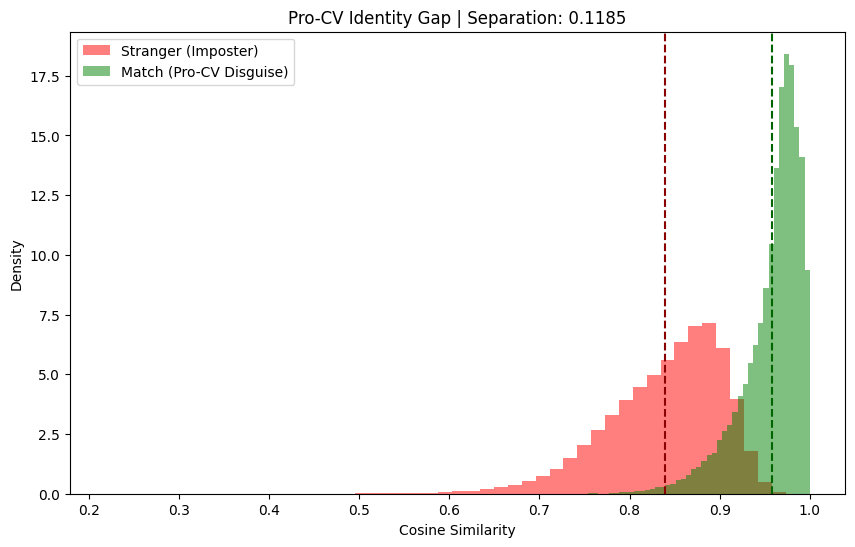

📊 PRO-CV RESULTS
Mean Match: 0.9580
Mean Stranger: 0.8394
SEPARATION GAP: 0.1185


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pathlib import Path
from tqdm import tqdm

# ==========================================
# 1. SETUP (Ensure paths match your PC)
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pro_cv_path = r"C:\Users\kaksh\Documents\SMU MITB\Pro_CV_Disguise_flat"
# ==========================================
# 2. THE UNIVERSAL EXTRACTOR (With L2 Fix)
# ==========================================
vit_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def extract_vector(model, img_path, device):
    try:
        img = Image.open(img_path).convert('RGB')
        img_t = vit_transforms(img).unsqueeze(0).to(device)
        with torch.no_grad():
            # Handle both raw ViT and our Wrapper
            features = model.encoder(img_t) if hasattr(model, 'encoder') else model(img_t)
            normalized_features = F.normalize(features, p=2, dim=1)
        return normalized_features.cpu().numpy().flatten()
    except Exception:
        return None

# ==========================================
# 3. ANALYSIS LOOP (Look for 'pro_' files)
# ==========================================
def run_pro_cv_gap_analysis(model, dataset_root):
    dataset_path = Path(dataset_root)
    all_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    match_scores = []
    original_embs = []

    for person_dir in tqdm(all_dirs, desc="Analyzing Pro-CV"):
        all_imgs = list(person_dir.glob('*.[jp][pn][g]*'))
        orig_path = next((i for i in all_imgs if "00_original" in i.name), None)
        # Look specifically for our landmark-anchored disguises
        pro_paths = [i for i in all_imgs if "pro_" in i.name]
        
        if orig_path and pro_paths:
            o_emb = extract_vector(model, orig_path, device)
            if o_emb is not None:
                original_embs.append(o_emb)
                for p_path in pro_paths:
                    p_emb = extract_vector(model, p_path, device)
                    if p_emb is not None:
                        match_scores.append(np.dot(o_emb, p_emb))

    # Calculate Stranger Scores
    imposter_matrix = np.vstack(original_embs)
    sim_matrix = np.dot(imposter_matrix, imposter_matrix.T)
    mask = np.ones(sim_matrix.shape, dtype=bool)
    np.fill_diagonal(mask, False)
    stranger_scores = sim_matrix[mask]

    return np.array(match_scores), stranger_scores



matches, strangers = run_pro_cv_gap_analysis(base_model, pro_cv_path)

# Final Visualization
plt.figure(figsize=(10, 6))
plt.hist(strangers, bins=50, alpha=0.5, color='red', label='Stranger (Imposter)', density=True)
plt.hist(matches, bins=50, alpha=0.5, color='green', label='Match (Pro-CV Disguise)', density=True)
plt.axvline(x=np.mean(strangers), color='darkred', linestyle='--')
plt.axvline(x=np.mean(matches), color='darkgreen', linestyle='--')

gap = np.mean(matches) - np.mean(strangers)
plt.title(f'Pro-CV Identity Gap | Separation: {gap:.4f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"📊 PRO-CV RESULTS")
print(f"Mean Match: {np.mean(matches):.4f}")
print(f"Mean Stranger: {np.mean(strangers):.4f}")
print(f"SEPARATION GAP: {gap:.4f}")

# Thresholding